In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import cv2 as cv
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
import math
from pathlib import Path
import os

In [8]:
data = pd.read_csv('../data/03_dataset_w_features.csv')
total_y = data[data['total_y'] == 0].value_counts().sum()
total_x = data[data['total_x'] == 0].value_counts().sum()
mask = (data['total_x'] == 0.0) & (data['total_y'] == 0.0)
print(mask.sum())
print(total_y, total_x)

5
14 10


In [81]:
path = '../ISIC/Test/nevus/ISIC_0000001.jpg'
print(Path(path).stem)

ISIC_0000001


In [20]:
device = torch.device('mps')

In [21]:
model = smp.Unet(encoder_name='efficientnet-b0', encoder_weights='imagenet', in_channels=3, classes=1).to(device)

In [22]:
model.load_state_dict(torch.load('../data/model_weights_skin_segmentation_ham10000.pth', map_location='mps'))

<All keys matched successfully>

In [23]:
def segmentate(image_path, model):
    img = cv.imread(image_path)
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img = cv.resize(img, (256,256))
    img = img.astype('float32') / 255.0
    img_tensor = torch.tensor(img).permute(2,0,1).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        output = torch.sigmoid(output).cpu().squeeze().numpy()
        mask = (output > 0.3).astype(np.uint8)

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.title("Original image")
    plt.imshow(img)

    plt.subplot(1,2,2)
    plt.title("Mask")
    plt.imshow(mask, cmap='gray')

    return mask
    

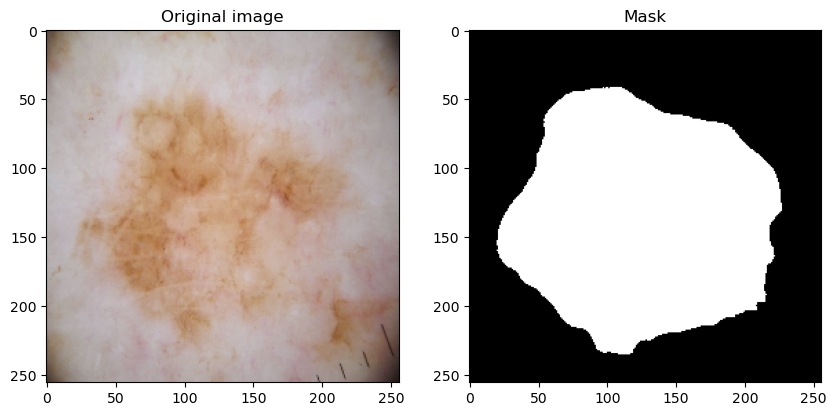

In [113]:
path = '../ISIC/Train/melanoma/ISIC_0000413.jpg'
mask = segmentate(path, model)

In [94]:
# Extracción de características se regirá por la regla ABCD
# A Asimetría
# B Borde
# C Color
# D diámetro

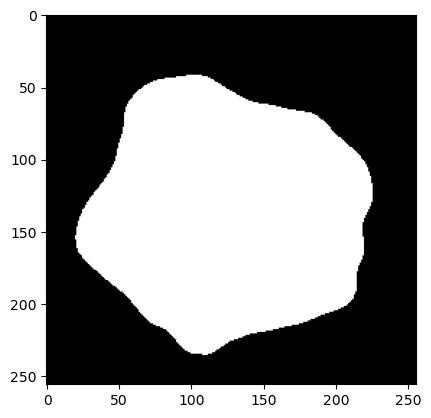

In [114]:
# Apply blur to the mask
kernel = np.ones((15,15), np.uint8)
morph_op = cv.morphologyEx(mask, cv.MORPH_DILATE, kernel, iterations=1)
morph_op = cv.morphologyEx(morph_op, cv.MORPH_ERODE, kernel, iterations=1)

blur_mask = cv.blur(morph_op, (15,15)).astype(np.uint8)
plt.imshow(blur_mask, cmap='gray')

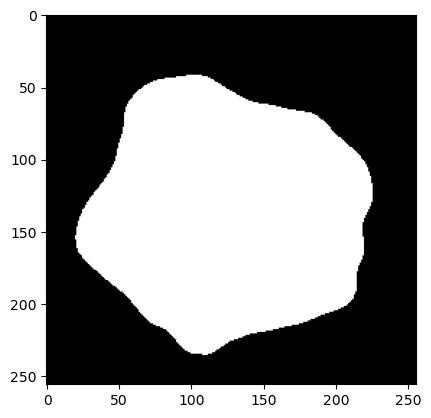

In [115]:
(h,w) = mask.shape[:2]
mask_contours = np.zeros((h,w))
edges = cv.Canny(blur_mask, 100, 200)

contours, hierarchy = cv.findContours(blur_mask, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

contour_max = max(contours, key=cv.contourArea)

cv.drawContours(mask_contours, [contour_max], -1, 255, -1)
plt.imshow(mask_contours, cmap='gray')

In [116]:
len(contour_max)

272

El diametro es: 206


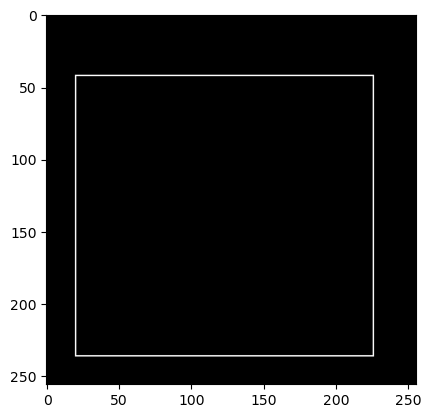

In [117]:
mask_bounding_rectangle = np.zeros((h,w))
x,y,w,h = cv.boundingRect(mask_contours.astype(np.uint8))
cv.rectangle(mask_bounding_rectangle, (x,y), (x+w, y+h), 255)
plt.imshow(mask_bounding_rectangle, cmap='gray')
diameter = max(w,h)
print(f"El diametro es: {diameter}")

In [118]:
# Borde
# Para esto calculamos circularidad
# Necesitamos área y el perimetro anteriormente calculado
perimeter = cv.arcLength(contour_max, True)
area = cv.contourArea(contour_max)

if perimeter > 0:
    circularity = ((4*math.pi*area)/(perimeter*perimeter))


print(circularity)


0.8087216175668436


In [119]:
# image_original = cv.imread(path, cv.IMREAD_COLOR_RGB).astype(np.uint8)
# image_original = cv.resize(image_original, (256,256))

# res = cv.bitwise_and(image_original, image_original, mask=contour_max)

# plt.imshow(image_original)
# plt.imshow(blur_mask, cmap='jet', alpha=0.5)

In [120]:
# Asimetría

mask_flip_y = cv.flip(mask_contours, 1)
mask_flip_x = cv.flip(mask_contours, 0)

symmetry_comparison_y = cv.absdiff(mask_contours, mask_flip_y)
symmetry_comparison_x = cv.absdiff(mask_contours, mask_flip_x)

total_y = np.sum(symmetry_comparison_y)/area
total_x = np.sum(symmetry_comparison_x)/area

print(total_y, total_x)


55.264974473286834 85.15280074782484


{'m00': 7163970.0, 'm10': 892243725.0, 'm01': 989011890.0, 'm20': 128886543885.0, 'm11': 123826796655.0, 'm02': 151487971890.0, 'm30': 20530148222175.0, 'm21': 17971461170835.0, 'm12': 18989997125055.0, 'm03': 25011714449520.0, 'mu20': 17761167201.139572, 'mu11': 649333209.0489208, 'mu02': 14951314343.78303, 'mu30': 53681963087.71247, 'mu21': 16465361850.902796, 'mu12': -56507656577.44001, 'mu03': -29912009755.186962, 'nu20': 0.00034607002604779166, 'nu11': 1.2652026639039705e-05, 'nu02': 0.0002913210424633429, 'nu30': 3.907904956775128e-07, 'nu21': 1.1986348019185496e-07, 'nu12': -4.1136079705935825e-07, 'nu03': -2.1775152111782105e-07}
124 138
angulo ((124.43217468261719, 138.23460388183594), (180.68585205078125, 199.1704864501953), 103.82781219482422)


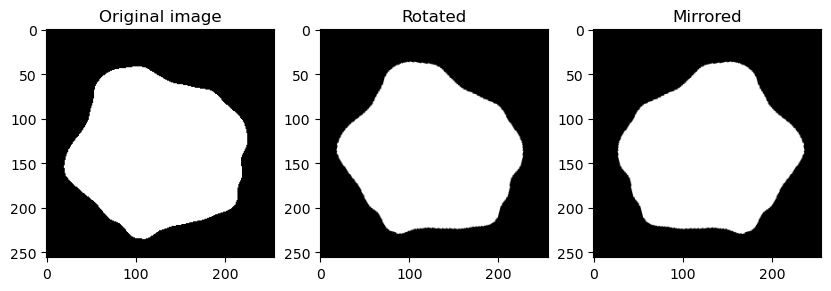

In [123]:
# Asimetría 2


#Copy of mask contours

mask_contours_copy = mask_contours.copy()
((h_mask, w_mask)) = mask_contours_copy.shape[:2]

# Find the center of the lesion

moments = cv.moments(mask_contours)

# Centroid

cX = int(moments['m10']/moments['m00'])
cY = int(moments['m01']/moments['m00'])

print(moments)
print(cX, cY)

# Angle

angle = cv.fitEllipse(contour_max)

print(f"angulo {angle}")



rotation_matrix = cv.getRotationMatrix2D((cX, cY), 90-angle[2], 1.0)


rotated = cv.warpAffine(mask_contours_copy, rotation_matrix, (h_mask, w_mask))

# mirrored

mirrored_y = cv.flip(rotated, 1)
mirrored_x = cv.flip(rotated, 0)



plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.title("Original image")
plt.imshow(mask_contours, cmap='gray')

plt.subplot(1,3,2)
plt.title("Rotated")
plt.imshow(rotated, cmap='gray')


plt.subplot(1,3,3)
plt.title("Mirrored")
plt.imshow(mirrored_y, cmap='gray')

# Intersection

inter_y = np.sum(cv.bitwise_and(rotated, mirrored_y) > 0)

# Union

union_y = np.sum(cv.bitwise_or(rotated, mirrored_y) > 0)



asymmetry_index_y = inter_y / union_y


####


inter_x = np.sum(cv.bitwise_and(rotated, mirrored_x) > 0)

# Union

union_x = np.sum(cv.bitwise_or(rotated, mirrored_x) > 0)



asymmetry_index_x = inter_x / union_y





In [122]:
image_original

NameError: name 'image_original' is not defined

saturation std: 10.214249332287006 vue std 5.424435030479015


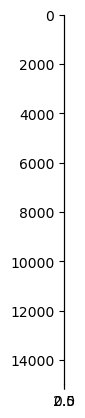

In [ ]:
# Color variation

image_original = cv.imread(path).astype(np.uint8)
image_original_hsv = cv.cvtColor(image_original, cv.COLOR_BGR2HSV)
image_original_hsv = cv.resize(image_original, (256,256))

res = cv.bitwise_and(image_original_hsv, image_original_hsv, mask=mask_contours.astype(np.uint8))

res_test = res[mask_contours > 0]

# Split color channels

h,s,v = cv.split(res)

s = s[mask_contours>0]
v = v[mask_contours>0]

saturation_std = np.std(s)
vue_std = np.std(v)

print(f"saturation std: {saturation_std} vue std {vue_std}")

plt.imshow(res_test)
